## House Price Prediction — Ames Housing Dataset

**Objective:** Predict the sale price of residential homes from their features, and 
identify which factors most influence price.

**Dataset:** The Ames Housing dataset contains 1,460 residential home sales in Ames, 
Iowa, described by 79 features covering size, quality, location, and condition.

**Approach:** This project covers data cleaning and missing-value treatment, exploratory 
data analysis, categorical encoding, comparison of five regression models, and buyer 
recommendations based on value and budget.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd .read_csv("/Users/varshith/house_project/data.csv")

In [3]:
df.shape

(1460, 81)

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
df.isnull().sum().sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


To assess data quality, we counted missing values per column and filtered to those with gaps, revealing 19 affected columns. The counts clustered in groups all five Garage columns had exactly 81 missing, and the Basement columns 37  indicating that these gaps represent houses without that feature rather than lost data. This distinction determined the imputation strategy.

In [9]:
df['PoolQC'] = df['PoolQC'].fillna('None')

PoolQC had 1,453 missing values out of 1,460. Rather than dropping the column, we examined what the missing values represented: consulting the data description confirmed that a blank indicates the house has no pool, not lost data. We therefore imputed "None", preserving the information that these houses lack a pool while retaining the genuine quality ratings for the 7 houses that do have one.

In [10]:
df['PoolQC'].isnull().sum()

np.int64(0)

In [11]:
df['PoolQC'].value_counts()

PoolQC
None    1453
Gd         3
Ex         2
Fa         2
Name: count, dtype: int64

In [12]:
none_cols = ['MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtCond', 'BsmtQual']

Fourteen categorical columns shared the same characteristic: a missing value indicated the house lacked that feature entirely (no garage, no basement, no fireplace, etc.) rather than a recording error. These were grouped into a single list and imputed with "None" using a loop, preserving the meaningful absence rather than discarding the information.

In [13]:
for col in none_cols:
    df[col] = df[col].fillna('none')

In [14]:
df[none_cols].isnull().sum()

MiscFeature     0
Alley           0
Fence           0
FireplaceQu     0
MasVnrType      0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtFinType2    0
BsmtExposure    0
BsmtFinType1    0
BsmtCond        0
BsmtQual        0
dtype: int64

In [15]:
zero_cols = ['GarageYrBlt', 'MasVnrArea']

for col in zero_cols:
    df[col] = df[col].fillna(0)

In [16]:
df[zero_cols].isnull().sum()

GarageYrBlt    0
MasVnrArea     0
dtype: int64

In [17]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [18]:
df[['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'Electrical']].isnull().sum()

LotFrontage    0
GarageYrBlt    0
MasVnrArea     0
Electrical     1
dtype: int64

In [19]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [20]:
df['Electrical'].isnull().sum()

np.int64(0)

In [21]:
df.isnull().sum().sum()

np.int64(0)

In [22]:
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

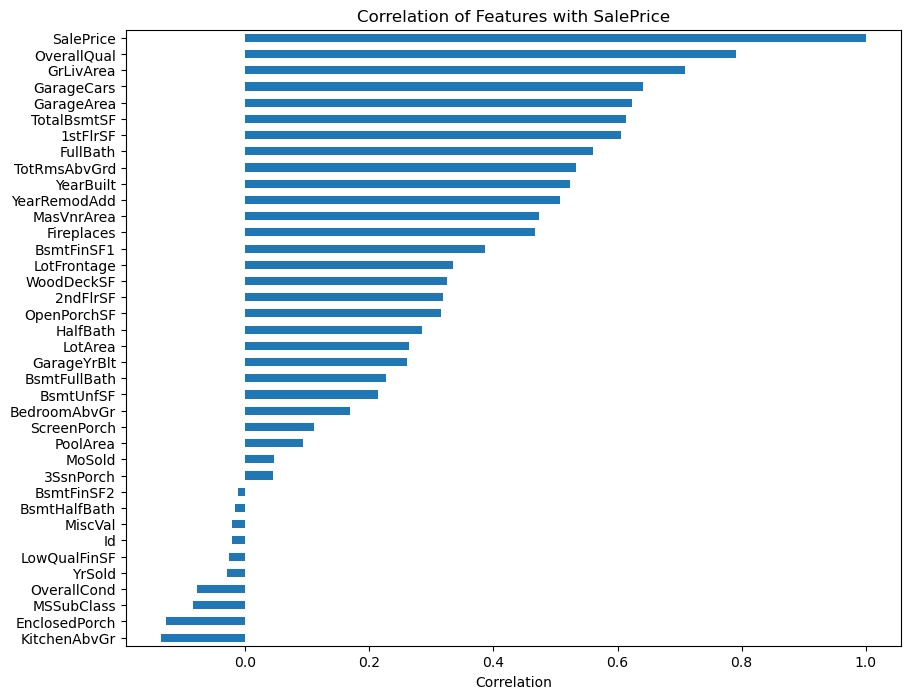

In [23]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr.plot(kind='barh')
plt.title('Correlation of Features with SalePrice')
plt.xlabel('Correlation')
plt.gca().invert_yaxis()
plt.show()

In [24]:
corr = corr.drop('SalePrice')

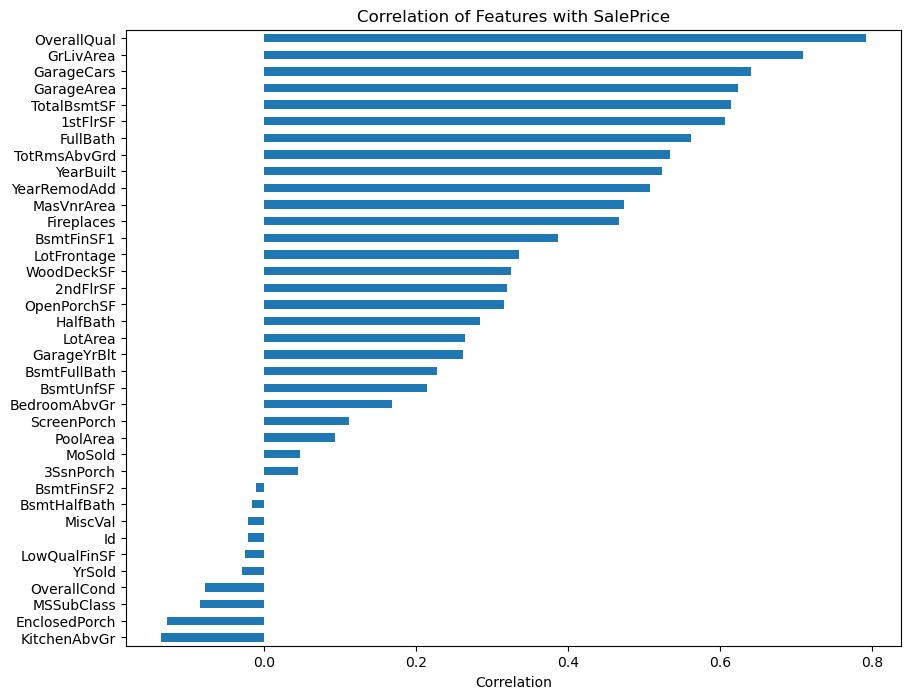

In [25]:
plt.figure(figsize=(10, 8))
corr.plot(kind='barh')
plt.title('Correlation of Features with SalePrice')
plt.xlabel('Correlation')
plt.gca().invert_yaxis()
plt.show()

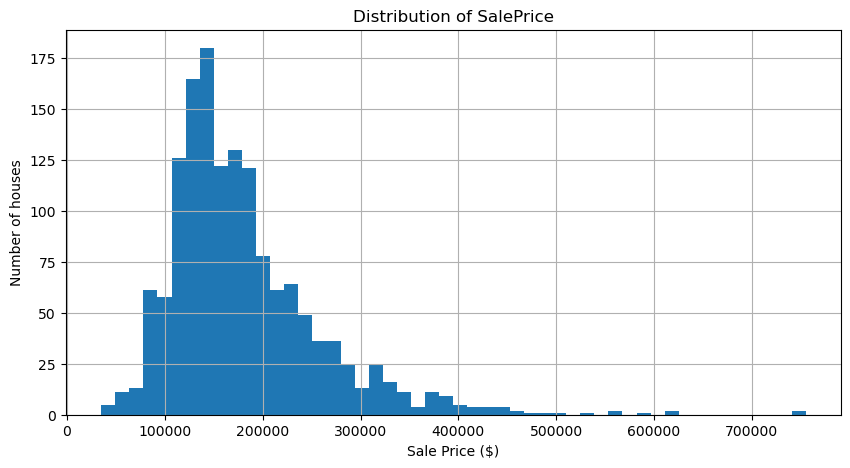

In [26]:
plt.figure(figsize=(10, 5))
df['SalePrice'].hist(bins=50)
plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of houses')
plt.show()

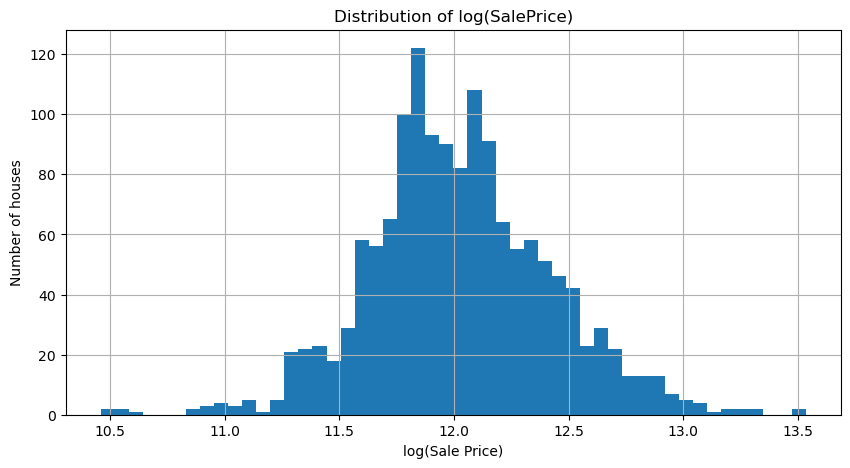

In [27]:
plt.figure(figsize=(10, 5))
np.log(df['SalePrice']).hist(bins=50)
plt.title('Distribution of log(SalePrice)')
plt.xlabel('log(Sale Price)')
plt.ylabel('Number of houses')
plt.show()

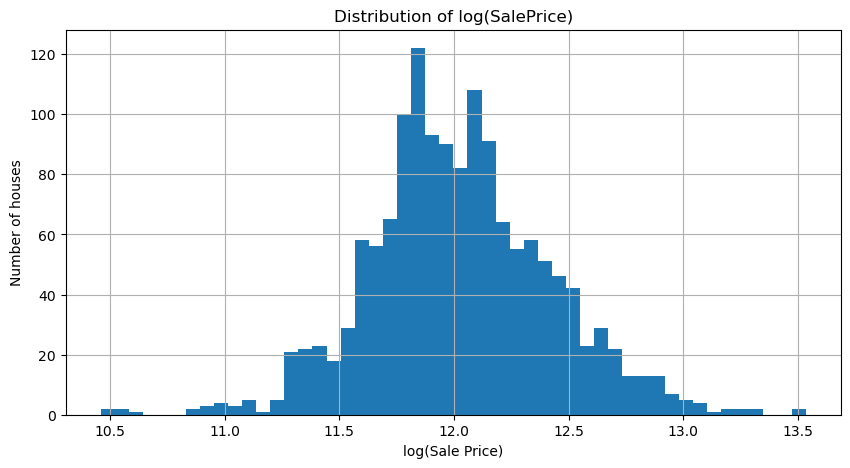

In [28]:
plt.figure(figsize=(10, 5))
np.log(df['SalePrice']).hist(bins=50)
plt.title('Distribution of log(SalePrice)')
plt.xlabel('log(Sale Price)')
plt.ylabel('Number of houses')
plt.show()

The raw SalePrice distribution is right-skewed. Skewed targets can weaken linear models, which assume normally distributed values. After applying a log transformation, the distribution becomes approximately symmetric (bell-shaped). Therefore, we will model log(SalePrice) instead of raw SalePrice to improve prediction accuracy and reduce the effect of extreme high-priced houses.

In [29]:
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

The goal is to show the average sale price for each neighborhood, to see which areas are expensive vs cheap.

now we are visualzing it to a horizental barsheet

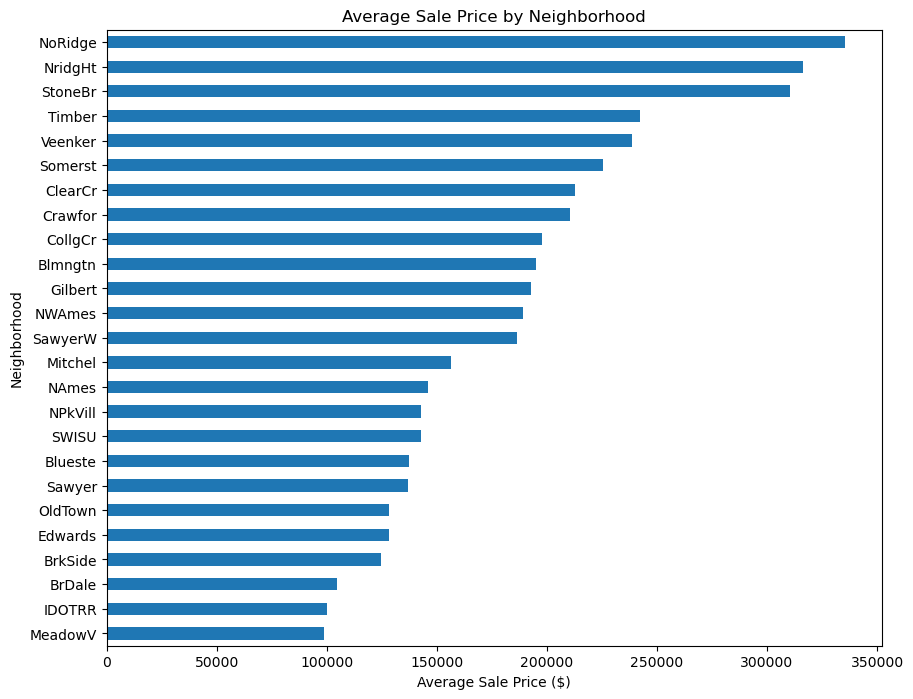

In [30]:
neighborhood_prices = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
neighborhood_prices.plot(kind='barh')
plt.title('Average Sale Price by Neighborhood')
plt.xlabel('Average Sale Price ($)')
plt.gca().invert_yaxis()
plt.show()

Average sale price varies a lot by neighborhood. The most expensive area (NoRidge) is around three times higher than the cheapest (MeadowV). This shows that location is one of the strongest factors affecting house price. However, because Neighborhood is a text column, it did not appear in the earlier numeric correlation analysis. This is an important reason why we need to encode categorical features before modeling, so the model can use location information.

## preparing the data for modeling 

we are doing the encodoing now because the goal is to identify the ordered and quality columns, so the once with the real ranking (Ex > Gd > TA > Fa > Po)

We'll map these to numbers that respect the order (ordinal encoding).

next, One-hot encode everything else — the unordered text columns (Neighborhood, MSZoning, etc)

In [31]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

we have created one mapping dictinory and applied to all beacause they share the same scale.

then we are making a list of quality columns

In [32]:
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                'GarageQual', 'GarageCond', 'PoolQC']

Then we are looping them by applying the map

In [33]:
for col in quality_cols:
    df[col] = df[col].map(quality_map)

In [34]:
df[quality_cols].isnull().sum()

ExterQual        0
ExterCond        0
BsmtQual        37
BsmtCond        37
HeatingQC        0
KitchenQual      0
FireplaceQu    690
GarageQual      81
GarageCond      81
PoolQC           0
dtype: int64

so we have got the missing values data

In [35]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

In [36]:
df['FireplaceQu'].value_counts(dropna=False)

FireplaceQu
NaN    690
4.0    380
3.0    313
2.0     33
5.0     24
1.0     20
Name: count, dtype: int64

we are making of list of the 4 affected columns and loop fill with 0

In [37]:
missing_after_map = ['BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in missing_after_map:
    df[col] = df[col].fillna(0)

this says for each of these columns, fill the NaN (no basement / no fireplace / no garage) with 0.

In [38]:
df[quality_cols].isnull().sum()

ExterQual      0
ExterCond      0
BsmtQual       0
BsmtCond       0
HeatingQC      0
KitchenQual    0
FireplaceQu    0
GarageQual     0
GarageCond     0
PoolQC         0
dtype: int64

now all the 10 columns are 0

In [39]:
# ===== MASTER DATA PREP =====

# 1. Load
df = pd.read_csv("/Users/varshith/house_project/data.csv")

# 2. Fill "None" text columns (feature absent)
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtCond', 'BsmtQual']
for col in none_cols:
    df[col] = df[col].fillna('None')

# 3. Fill "0" number columns (feature absent)
zero_cols = ['GarageYrBlt', 'MasVnrArea']
for col in zero_cols:
    df[col] = df[col].fillna(0)

# 4. Fill genuinely-unknown columns
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# 5. Ordinal-encode the quality columns
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                'GarageQual', 'GarageCond', 'PoolQC']
for col in quality_cols:
    df[col] = df[col].map(quality_map)

# 6. One-hot encode remaining categorical columns   ← ADD THIS
df = pd.get_dummies(df)

print("Prep done. Shape:", df.shape)
print("Missing values total:", df.isnull().sum().sum())

Prep done. Shape: (1460, 264)
Missing values total: 0


## One-hot encoding takes each text column and splits it into one yes/no column per category

next we will seperate the features x from y

In [40]:
y = np.log(df['SalePrice'])
X = df.drop(columns=['SalePrice', 'Id'])

In [41]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 262)
y shape: (1460,)


after seperting we have to train, test and split the data 

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1168, 262)
X_test: (292, 262)


next we will Train models (Linear Regression, Random Forest, gradient boosting)

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_predictions)
print("Linear Regression MAE:", lr_mae)

Linear Regression MAE: 0.08797257238569513


In [44]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
print("Random Forest MAE:", rf_mae)

Random Forest MAE: 0.09854667983012494


In [45]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(n_estimators=100, random_state=42)
lgb_model.fit(X_train, y_train)

lgb_predictions = lgb_model.predict(X_test)
lgb_mae = mean_absolute_error(y_test, lgb_predictions)
print("LightGBM MAE:", lgb_mae)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3196
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 168
[LightGBM] [Info] Start training from score 12.030652
LightGBM MAE: 0.09069184982558193


## overfitting 

In [46]:
train_pred = rf_model.predict(X_train)
train_mae = mean_absolute_error(y_train, train_pred)
print("RF Train MAE:", train_mae)
print("RF Test MAE:", rf_mae)

RF Train MAE: 0.03548403604179456
RF Test MAE: 0.09854667983012494


The Random Forest achieved a much lower error on training data (0.035) than on test data (0.099), indicating overfitting — it memorized the training houses but generalized poorly. This is likely due to the small dataset (1,168 rows) combined with many features (262). The simpler Linear Regression was less prone to overfitting, which contributed to its stronger test performance.

## cross-validation

In [47]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-val MAE scores:", -cv_scores)
print("Average CV MAE:", -cv_scores.mean())

Cross-val MAE scores: [0.09113589 0.09529544 0.09475988 0.08168117 0.09555887]
Average CV MAE: 0.09168624824956387


In [48]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(15))

OverallQual     0.542036
GrLivArea       0.112237
TotalBsmtSF     0.041576
GarageCars      0.039204
GarageArea      0.021439
BsmtFinSF1      0.020796
1stFlrSF        0.019610
LotArea         0.015117
YearBuilt       0.014228
FireplaceQu     0.011140
OverallCond     0.009949
BsmtQual        0.009536
YearRemodAdd    0.008437
CentralAir_Y    0.007813
GarageYrBlt     0.007810
dtype: float64


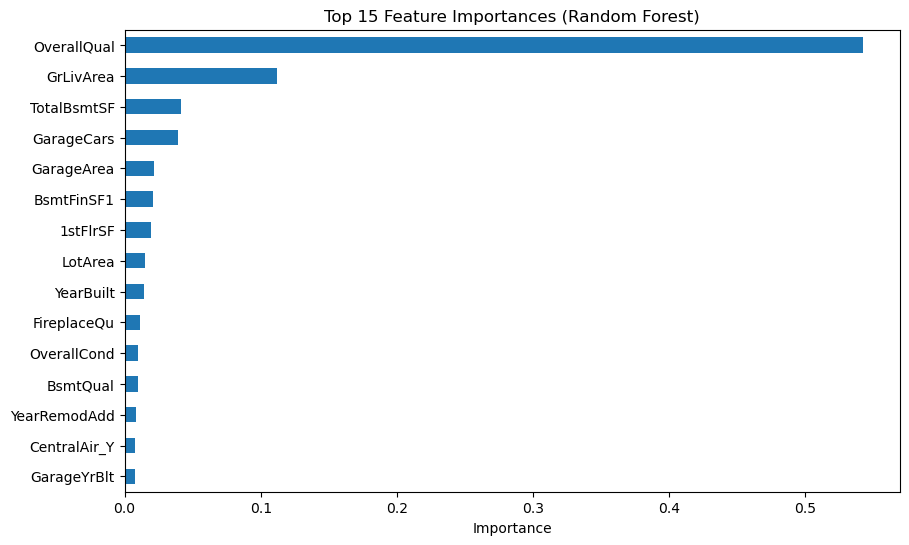

In [49]:
plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                    param_grid, cv=3, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV MAE: 0.09566417999285748


now lets calculate price per square foot by neighborhood → low = good value → recommend those areas to budget-conscious buyers

In [51]:
df_raw = pd.read_csv("/Users/varshith/house_project/data.csv")
df_raw['price_per_sqft'] = df_raw['SalePrice'] / df_raw['GrLivArea']
value = df_raw.groupby('Neighborhood')['price_per_sqft'].mean().sort_values()
print(value)

Neighborhood
SWISU       84.755233
IDOTRR      89.136043
OldTown     91.427282
BrDale      91.950543
Blueste     98.969369
Edwards    101.832958
MeadowV    101.926201
BrkSide    105.966809
NWAmes     111.848349
NAmes      116.089385
NPkVill    116.726891
Sawyer     117.856163
Gilbert    119.114931
SawyerW    119.704424
Crawfor    120.254826
ClearCr    124.242989
Mitchel    126.017449
NoRidge    132.271687
Blmngtn    136.566974
CollgCr    136.783680
Timber     139.766483
Somerst    141.335966
Veenker    154.980914
NridgHt    164.578057
StoneBr    165.402275
Name: price_per_sqft, dtype: float64


Best value (lowest price per sq ft):

SWISU → \$84.76/sqft
IDOTRR → \$89.14
OldTown → \$91.43
BrDale → \$91.95



Most expensive per sq ft:

StoneBr → \$165.40
NridgHt → \$164.58
Veenker → \$154.98

you pay roughly 2× more per square foot in StoneBr than SWISU. A buyer in SWISU gets nearly double the space for the same money.

budget based recommendation

In [52]:
budget = 150000

affordable = df_raw[df_raw['SalePrice'] <= budget]

print("Houses within budget:", len(affordable), "out of", len(df_raw))
print()
print("Neighborhoods with the most options under $150k:")
print(affordable['Neighborhood'].value_counts().head(8))

Houses within budget: 619 out of 1460

Neighborhoods with the most options under $150k:
Neighborhood
NAmes      147
OldTown     92
Edwards     81
Sawyer      57
BrkSide     47
CollgCr     36
IDOTRR      35
Mitchel     23
Name: count, dtype: int64


In [53]:
print("Typical house under $150k:")
print("  Avg size (GrLivArea):", round(affordable['GrLivArea'].mean()), "sq ft")
print("  Avg quality (OverallQual):", round(affordable['OverallQual'].mean(), 1), "/ 10")
print("  Avg year built:", round(affordable['YearBuilt'].mean()))
print("  Avg price:", round(affordable['SalePrice'].mean()))

Typical house under $150k:
  Avg size (GrLivArea): 1180 sq ft
  Avg quality (OverallQual): 5.0 / 10
  Avg year built: 1952
  Avg price: 119778


now lets score our linear regression 3 ways which are (Mean Absolute Error, Root Mean Squared Error, R-squared)
MAE (Mean Absolute Error) → on average, how far off are the predictions
RMSE (Root Mean Squared Error) → similar, but it punishes big misses harder. If the model is wildly wrong on one house, RMSE reflects that more than MAE does.
R² (R-squared) → what fraction of the variation in price does the model explain? Ranges 0 to 1. An R² of 0.87 means "the model explains 87% of why prices differ."

In [54]:
from sklearn.metrics import mean_squared_error, r2_score

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression:")
print("  MAE :", round(lr_mae, 4))
print("  RMSE:", round(lr_rmse, 4))
print("  R2  :", round(lr_r2, 4))

Linear Regression:
  MAE : 0.088
  RMSE: 0.1258
  R2  : 0.9152


 code is a function that evaluates all three of our models and puts the results in one table

In [55]:
def evaluate(name, model):
    tr = model.predict(X_train)
    te = model.predict(X_test)
    return {
        'Model': name,
        'Train MAE': round(mean_absolute_error(y_train, tr), 4),
        'Test MAE': round(mean_absolute_error(y_test, te), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, te)), 4),
        'Test R2': round(r2_score(y_test, te), 4)
    }

results = pd.DataFrame([
    evaluate('Linear Regression', lr_model),
    evaluate('Random Forest', rf_model),
    evaluate('LightGBM', lgb_model)
])
print(results)

               Model  Train MAE  Test MAE  Test RMSE  Test R2
0  Linear Regression     0.0657    0.0880     0.1258   0.9152
1      Random Forest     0.0355    0.0985     0.1458   0.8862
2           LightGBM     0.0249    0.0907     0.1371   0.8993


overfitting is a problem when a model has when it performs much better on training data than on unseen test data. It means the model memorized rather than learned.


we detect it by training MAE

Underfitting = bad on both train data and test data

By comparing training and test MAE for each model, we detected clear overfitting in both tree-based models — LightGBM performed nearly 4× better on training data (0.025) than test data (0.091), and Random Forest showed a similar pattern. Linear Regression had the smallest train-test gap (0.022), indicating it generalized best. No model showed underfitting.


In [56]:
from sklearn.linear_model import Ridge, Lasso

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train, y_train)

print(pd.DataFrame([
    evaluate('Linear Regression', lr_model),
    evaluate('Ridge', ridge_model),
    evaluate('Lasso', lasso_model),
    evaluate('Random Forest', rf_model),
    evaluate('LightGBM', lgb_model)
]))

               Model  Train MAE  Test MAE  Test RMSE  Test R2
0  Linear Regression     0.0657    0.0880     0.1258   0.9152
1              Ridge     0.0710    0.0895     0.1246   0.9167
2              Lasso     0.0814    0.0936     0.1375   0.8987
3      Random Forest     0.0355    0.0985     0.1458   0.8862
4           LightGBM     0.0249    0.0907     0.1371   0.8993


Linear Regression is winning. Ridge and Lasso are regularized versions of Linear Regression — same idea, but with a penalty that stops the model relying too heavily on any single feature

Ridge — shrinks all coefficients toward zero, reducing over-reliance on any feature
Lasso — shrinks and can push some coefficients to exactly zero, effectively doing automatic feature selection (useful with 262 features!)

# Conclusion


## What was built:

A model predicting Ames house prices from 1,460 houses and 79 original features (expanded to 262 after encoding), covering cleaning, EDA, encoding, model comparison, and buyer recommendations.


## Model performance: 

Linear Regression performed best overall, with a test MAE of 0.088 and R² of 0.915 (explains ~91.5% of price variation). Ridge was essentially tied, edging it out slightly on RMSE (0.1246 vs 0.1258) and R² (0.917).

## What drives price: 

OverallQual dominates feature importance at 54.2%, followed by GrLivArea at 11.2% — confirming quality and size are the primary drivers. Location matters too: average price ranges from $335,295 (NoRidge) to $98,576 (MeadowV), a ~3.4x spread.

## Simple beat complex: 

LightGBM scored 0.025 MAE on training data but only 0.091 on test — a clear overfitting signature also present in Random Forest (0.036 → 0.099). The train-test gap shrank as regularization increased: Lasso (0.012) < Ridge (0.019) < Linear Regression (0.022) < Random Forest (0.063) < LightGBM (0.066). With only 1,168 training rows against 262 features, tree models had too much room to memorize; grid-search tuning narrowed but didn't close the gap.

## Buyer recommendations: 

SWISU offers the best value at $84.76/sqft vs. $165.40/sqft in StoneBr — roughly double the space per dollar. 619 of 1,460 houses (42.4%) fall under $150,000, with NAmes having the most options (147). A typical sub-$150k house is ~1,180 sqft, quality 5/10, built around 1952.

## Production recommendation:

Linear Regression (or Ridge) — best balance of accuracy, generalization, and interpretability, which matters for a pricing tool where users want to know why a price was predicted.

## Future improvements: 

reduce dimensionality (81→264 columns from one-hot encoding likely drove overfitting), tune Ridge/Lasso alpha via GridSearchCV instead of manual values, use target encoding for Neighborhood instead of one-hot (currently diluted across 25 columns), and get more training data.

## Challenges faced

## Encoding Broke 

on Already-Filled Columns after running the quality_map ('None': 0, ...) over quality_cols, BsmtQual, BsmtCond, FireplaceQu, GarageQual, and GarageCond came back with NaN counts identical to their original missing counts (37, 37, 690, 81, 81). 

The cause: the earlier none_cols fill used lowercase 'none', but quality_map only recognized capitalized 'None'. .map() treats unmatched values as missing, so the case mismatch silently reproduced the original NaNs. 

Fixed by re-filling those five columns with 0 directly, then standardizing on capitalized 'None' in the consolidated master cell so the fill and the map agreed.

## High Dimensionality from One-Hot Encoding

Onehot encoding expanded the dataset from 81 columns to 264, contributing directly to overfitting in the tree-based models (Random Forest and LightGBM scored far better on training data than test data, since 262 features against only 1,168 training rows gave them room to memorize rather than generalize). 

Noted as a fix: drop near-zero-importance columns, and use target encoding for Neighborhood instead of spreading it across 25 dummy columns.


## Missing values  

hoosing the Right MissingValue Strategy 19 columns had gaps, but a blanket drop or fill would have destroyed information, since most "missing" values meant a house lacked that feature entirely (no pool, no garage, no basement) rather than data being lost. Resolved with a four-category strategy based on what the gap actually meant: 'None' for absent categorical features (PoolQC, GarageType, etc.), 0 for absent numeric features (GarageYrBlt, MasVnrArea), median for a genuinely-unknown continuous value (LotFrontage), and mode for a genuinely-unknown categorical value (Electrical, 1 missing row)

## Data Analysis Report

## Dataset Overview
The Ames Housing dataset contains 1,460 houses described by 79 features (plus Id and the target, SalePrice). Of these, 43 are categorical (text) and 38 are numeric.

## Missing Values
19 columns contained missing values, ranging from PoolQC (1,453) to Electrical (1). The counts clustered — all Garage columns had exactly 81 missing, Basement columns ~37 — revealing that most gaps mean the feature is absent (no garage, no basement) rather than lost data. We therefore imputed by category: "None" for absent categorical features, 0 for absent numeric features, median for LotFrontage (genuinely unmeasured), and mode for Electrical.

## Target Distribution
SalePrice is right-skewed, with most homes in the lower-to-mid range and a long tail of expensive houses. A log transformation made the distribution approximately normal, so we modelled log(SalePrice) to improve linear model performance.

## Key Price Drivers
Correlation analysis showed OverallQual (0.79) and GrLivArea (0.71) as the strongest numeric predictors — quality and size dominate. Several size features were highly correlated with each other (multicollinearity), e.g. GarageCars and GarageArea.

## Location Analysis
Average price varied dramatically by neighborhood — from $335,295 (NoRidge) to $98,576 (MeadowV), a ~3.4x spread. Because Neighborhood is categorical, this was invisible to numeric correlation, highlighting the need for encoding.

## Feature Encoding
Quality columns (with a natural ranking Ex > Gd > TA > Fa > Po) were ordinally encoded to preserve order; unordered columns (Neighborhood, MSZoning, etc.) were one-hot encoded to avoid implying a false ranking. This expanded the dataset from 81 to 264 columns.